# Question 1: Bias-Variance Trade-off on UCI Efficiency
In this question, you will examine effice of the degree of polynomial feature under ridge reression.  The dataset is from UCI Energy efficiency https://archive.ics.uci.edu/dataset/242/energy+efficiency where 
- the features are 
    - Relative Compactness
    - Surface Area
    - Wall Area
    - Roof Area
    - Overall Height
    - Orientation
    - Glazing Area
    - Glazing Area Distribution
- the target is the Heating Load

## Setup

Use the provided notebook to load and standardize data



In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

train = pd.read_csv("q1_train.csv")
val   = pd.read_csv("q1_val.csv")
test  = pd.read_csv("q1_test.csv")

X_train, y_train = train.drop(columns=['Y1']), train['Y1']
X_val,   y_val   = val.drop(columns=['Y1']),   val['Y1']
X_test,  y_test  = test.drop(columns=['Y1']),  test['Y1']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)


Train: (460, 8) | Val: (154, 8) | Test: (154, 8)



## Model \& hyperparameters

Test all combination of Polynomial feature $K$ and strength of Ridge regularizater $\lambda$
- Degrees $K$ to try: 1, 2, 3, 4, 5, 6.
- Ridge $\lambda$ (suggested): 0, 1e-3, 1e-2, 1e-1, 1, 10, 100.

Fit the data by applying the psuedo-inverse approach of linear regression using polynomial features $x^k_j$, $k = 1,\dots, K$, where $x_j$ represents the $j$-th component of vector $x$.  For example, if $x = [x_1,x_2]$ and $k = 2$, then you’d have $4$ features, $x_1, x_2 , x_1^2, x_2^2$ along with an additional constant feature $1$ for the intercept term. 



Print the training and validation errors of above $6\times7$ combinations.


In [7]:
## TODO

from sklearn.preprocessing import PolynomialFeatures
#Basis function to convert original feature matrix row by row into polynomial terms of degree K 
def BasisFunction(X_train, X_val, X_test, degree, include_bias=True):
    poly = PolynomialFeatures(degree=degree, include_bias=include_bias)
    Phi_train = poly.fit_transform(X_train)
    Phi_val   = poly.transform(X_val)
    Phi_test  = poly.transform(X_test)
    return Phi_train, Phi_val, Phi_test

K =[1,2,3,4,5,6]# ploynomial degree terms were trying out 
ridge = [0,1e-3,1e-2,1e-1,1,10,100] #Ridge values for regularzation were trying out 

results = []

for k in K:  # loop over degrees
    Phi_train, Phi_val, Phi_test = BasisFunction(
        X_train, X_val, X_test, degree=k, include_bias=True
    ) # applying degree of polynomial values to our basis funciton so it can convert input matrix to corresponding polynomial degree 
    
    for r in ridge:  # loop over ridge penalties so we can try each one
        if r == 0: # if ridge is zero we need to apply least squaure psuedo inverse because regular ridge regression wont work matrix isnt invertible
            # ordinary least squares with pseudo-inverse 
            w = np.linalg.pinv(Phi_train) @ y_train # setting w to pseduo inverse formula with numpylibary linear algebra library using pseudo inverse of train matrix * target matrix 
            # which gives us least squared solution for w 
        else:
            # ridge regression closed form
            A = Phi_train.T @ Phi_train + r * np.eye(Phi_train.shape[1]) # tranposing matrix by its self to get square matrix and then adding regularzation values from ridge *
            # the idenity matrix which is a p*p matrix which has same number of columns from our identiy matrix so everthing is scaled correctly 
            w = np.linalg.solve(A, Phi_train.T @ y_train)
        
        # predictions
        train_preds = Phi_train @ w
        val_preds = Phi_val   @ w
        
        # mean squared errors
        mse_tr = np.mean((train_preds - y_train)** 2)
        mse_va = np.mean((val_preds - y_val)**2)
        
        # save result
        results.append((k, r, mse_tr, mse_va))
        



## Plots and reporting

Plot MSE vs degree with three curves (Train, Val, Test).  For each degree, use its best $\lambda$ (found on the validation set).


All results (42 combinations):
    Degree (k)   Lambda  Train_MSE    Val_MSE
0            1    0.000   8.775125   7.358253
1            1    0.001   8.775126   7.358426
2            1    0.010   8.775129   7.359985
3            1    0.100   8.775455   7.375478
4            1    1.000   8.794690   7.518570
5            1   10.000   9.315755   8.661504
6            1  100.000  27.175142  28.763185
7            2    0.000   0.502992   0.625711
8            2    0.001   0.894457   1.124923
9            2    0.010   0.950227   1.156053
10           2    0.100   2.172210   2.149530
11           2    1.000   4.922735   4.641354
12           2   10.000   6.910024   7.407833
13           2  100.000  18.573903  22.749977
14           3    0.000   0.154055   0.315155
15           3    0.001   0.154658   0.302006
16           3    0.010   0.161540   0.307480
17           3    0.100   0.285917   0.434728
18           3    1.000   1.149691   1.272506
19           3   10.000   3.909130   4.556463
20 

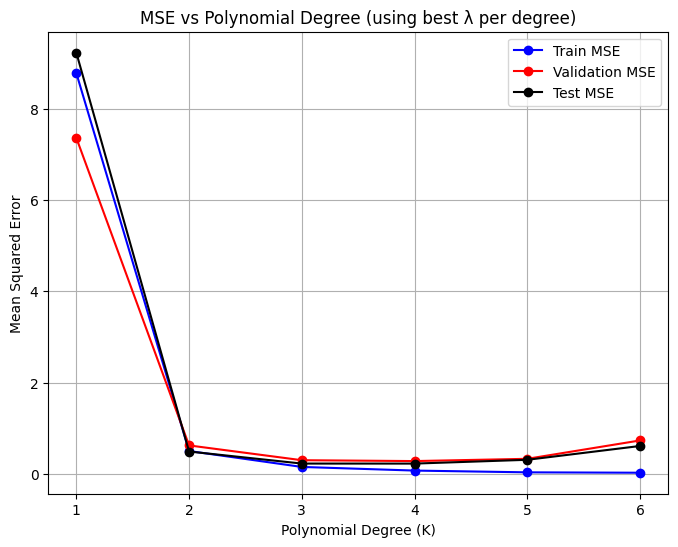

In [12]:
## TODO
import pandas as pd

# Convert results into DataFrame
df_results = pd.DataFrame(results, columns=["Degree (k)", "Lambda", "Train_MSE", "Val_MSE"])

# Print all 42 results as a table
print("All results (42 combinations):")
print(df_results)

# Find the best lambda (lowest validation MSE) for each degree
best_per_degree = df_results.loc[df_results.groupby("Degree (k)")["Val_MSE"].idxmin()]

print("\nBest lambda for each degree (based on validation MSE):")
print(best_per_degree)

plot_results = []

for _, row in best_per_degree.iterrows():
    k = int(row["Degree (k)"])
    best_lambda = row["Lambda"]

    # Build polynomial features for this degree
    Phi_train, Phi_val, Phi_test = BasisFunction(
        X_train, X_val, X_test, degree=k, include_bias=True
    )

    # Reuse the same formulas you already wrote
    if best_lambda == 0:
        w = np.linalg.pinv(Phi_train) @ y_train
    else:
        A = Phi_train.T @ Phi_train + best_lambda * np.eye(Phi_train.shape[1])
        w = np.linalg.solve(A, Phi_train.T @ y_train)

    # Predictions
    train_preds = Phi_train @ w
    val_preds   = Phi_val   @ w
    test_preds  = Phi_test  @ w

    # Compute MSE
    mse_tr = np.mean((train_preds - y_train)**2)
    mse_va = np.mean((val_preds - y_val)**2)
    mse_te = np.mean((test_preds - y_test)**2)

    plot_results.append((k, mse_tr, mse_va, mse_te))

# Put results into DataFrame
df_plot = pd.DataFrame(plot_results, columns=["Degree", "Train_MSE", "Val_MSE", "Test_MSE"])
print(df_plot)

# Plot
plt.figure(figsize=(8,6))
plt.plot(df_plot["Degree"], df_plot["Train_MSE"], marker="o",color= "blue" ,label="Train MSE")
plt.plot(df_plot["Degree"], df_plot["Val_MSE"], marker="o",color = "red", label="Validation MSE")
plt.plot(df_plot["Degree"], df_plot["Test_MSE"], marker="o",color = "black", label="Test MSE")
plt.xlabel("Polynomial Degree (K)")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Polynomial Degree (using best λ per degree)")
plt.legend()
plt.grid(True)
plt.show()



# Question 2: Weighted Linear Regression with an Unknown Variance Threshold

You will implement weighted least squares (WLS) for a linear model where the noise variance jumps at an unknown threshold $th$ on feature $x$. Specifically, 
$$y = x^\top w+\epsilon$$
with heterogenous Gaussian noise
$$\epsilon\sim \begin{cases}N(0, \sigma_S)\text{ if }x<th\\
N(0,\sigma_L)\text{ if }x\ge th\end{cases}$$
where $\sigma_L = 0.01$ and $\sigma_H = 1.0$.


In addition to unknown $w$, you also do not know $th$, but know it is between $-1$ and $1$.  You will compare orginal least squared solution (OLS) and weighted least squared solution (WLS) to estimate $th$ by validation search.


## Set up

Use the provided notebook to load the data.

In [13]:
# %% [markdown]
# Thresholded Heteroskedastic WLS
# You know σ_s and σ_L, but NOT the threshold t.
# For each candidate t, set weights r_i(t) and fit WLS, then pick t* via Val MSE.

import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ---------- Load data ----------
def load_xy(path):
    df = pd.read_csv(path)
    X = df[[c for c in df.columns if c.startswith("x")]].to_numpy()
    y = df["y"].to_numpy()
    # add intercept
    X = np.hstack([np.ones((X.shape[0],1)), X])
    return X, y

Xtr, ytr = load_xy("q2_train.csv")
Xva, yva = load_xy("q2_val.csv")
Xte, yte = load_xy("q2_test.csv")

print("Train:", Xtr.shape, "| Val:", Xva.shape, "| Test:", Xte.shape)

sigma_S = 0.01
sigma_L = 1.0

Train: (150, 2) | Val: (50, 2) | Test: (50, 2)


## Implement OLS and WLS 
- Implement OLS and WLW
- Plot Validation MSE vs $th$ where $x$-axis ithe candidate threshold and $y$ is the MSE on the validation dataset.  
- Report the MSE on the testing data of OLS and your best WLS.


--- OLS Results ---
Train MSE: 0.5127709030077987
Val   MSE: 0.4328706672090473
Test  MSE: 0.40167543553679075

Best tau (from Val set): -1.0

--- Best WLS Results ---
Train MSE: 0.5156739130175451
Val   MSE: 0.45430740848141793
Test  MSE: 0.41999523702915675


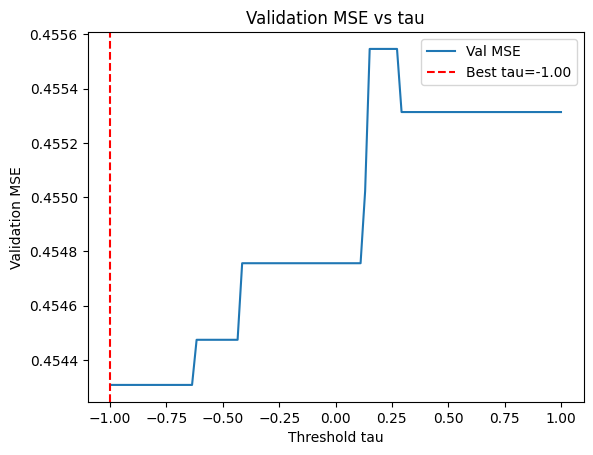

In [ ]:
## TODO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
#Ordinary Least Squares 
def ols_fit(X, y):
    return np.linalg.inv(X.T @ X) @ (X.T @ y)

def mse(X, y, w):
    y_pred = X @ w
    return np.mean((y - y_pred) ** 2)

w_ols = ols_fit(Xtr, ytr)
print("\n--- OLS Results ---")
print("Train MSE:", mse(Xtr, ytr, w_ols))
print("Val   MSE:", mse(Xva, yva, w_ols))
print("Test  MSE:", mse(Xte, yte, w_ols))

# Weigthed Least Squaress
def wls_fit(X, y, tau, sigma_S, sigma_L):
    # thresholding on feature column (first real feature is X[:,1])
    r = np.where(X[:, 1] < tau, 1 / sigma_S**2, 1 / sigma_L**2)
    R = np.diag(r)# make diagonial matrix with r which is either going to have distribution 1/sigma s ** 2 or 1/ sigma l **2
    return np.linalg.inv(X.T @ R @ X) @ (X.T @ R @ y) # and then computer closed form weighted least squares  with weight matrix R which we made above 

taus = np.linspace(-1, 1, 100)
val_errors = []

for tau in taus:
    w_wls = wls_fit(Xtr, ytr, tau, sigma_S, sigma_L)
    val_errors.append(mse(Xva, yva, w_wls))

best_tau = taus[np.argmin(val_errors)]
print("\nBest tau (from Val set):", best_tau)

# retrain with best tau
w_best = wls_fit(Xtr, ytr, best_tau, sigma_S, sigma_L)
print("\n--- Best WLS Results ---")
print("Train MSE:", mse(Xtr, ytr, w_best))
print("Val   MSE:", mse(Xva, yva, w_best))
print("Test  MSE:", mse(Xte, yte, w_best))

plt.plot(taus, val_errors, label="Val MSE")
plt.axvline(best_tau, color="r", linestyle="--", label=f"Best tau={best_tau:.2f}")
plt.xlabel("Threshold tau")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs tau")
plt.legend()
plt.show()



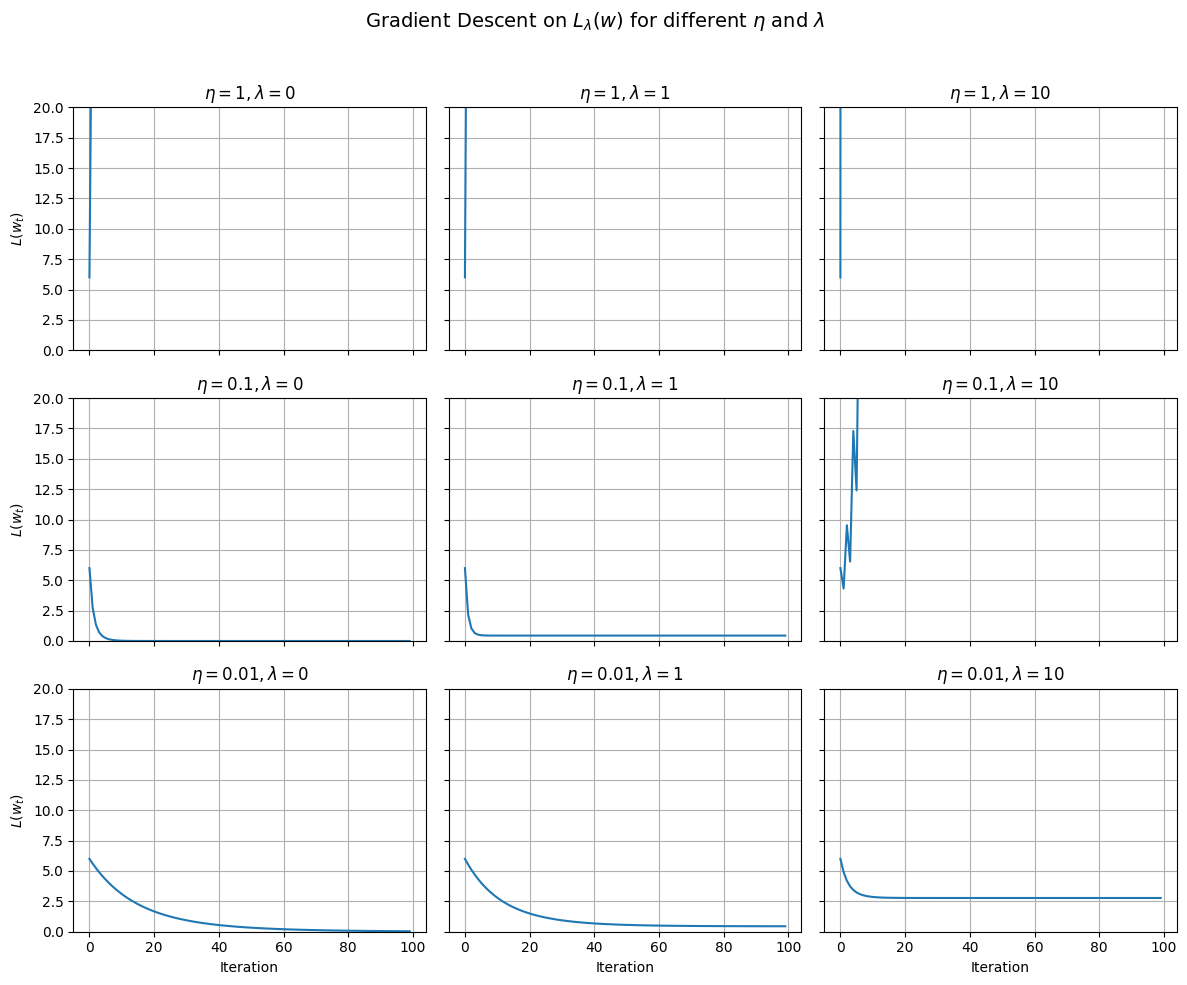

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def L(w):
    w1, w2, w3, w4 = w
    return (w1**2 + w2**2 + w3**2 +        #Quadratic loss function
            2*w1*w2 + w4**2 +
            4*w1 + 4*w2 + 4)

# Gradient of L(w)
def grad_L(w):
    w1, w2, w3, w4 = w
    return np.array([
        2*w1 + 2*w2 + 4,   # dL/dw1 # computing the partial dervative wrt to w so we can get slope of the quadratic loss function
        2*w2 + 2*w1 + 4,   # dL/dw2
        2*w3,              # dL/dw3
        2*w4               # dL/dw4
    ])

# Gradient of L_lambda(w) = L(w) + λ||w||^2
def grad_L_lambda(w, lam):
    return grad_L(w) + 2*lam*w    # computing gradient of loss function which we already did but with the lambda which is our regulazier
        # that penalizes large weights 


def gradient_descent(w0, eta, lam, steps=100):
    w = w0.copy() #Make a fresh copy of the starting weights so gradient descent can update them, while still remembering the original w0
    losses = []
    for t in range(steps):
        losses.append(L(w))             # record original L(w), not L_lambda
        grad = grad_L_lambda(w, lam)    # compute gradient
        w = w - eta * grad              # update rule
    return losses


etas = [1, 0.1, 0.01] # Step size
lambdas = [0, 1, 10] # regualizer strength 
w0 = np.array([0.0, 0.0, 1.0, 1.0])
steps = 100 


fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)

for i, eta in enumerate(etas):
    for j, lam in enumerate(lambdas):
        losses = gradient_descent(w0, eta, lam, steps)
        ax = axes[i, j]
        ax.plot(range(steps), losses, label=f"$\\eta={eta}, \\lambda={lam}$")
        ax.set_title(f"$\\eta={eta}, \\lambda={lam}$")
        ax.grid(True)
        ax.set_ylim(0, 20)  
        if i == 2:
            ax.set_xlabel("Iteration")
        if j == 0:
            ax.set_ylabel("$L(w_t)$")


plt.suptitle("Gradient Descent on $L_\\lambda(w)$ for different $\\eta$ and $\\lambda$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Ridge vs. Lasso: Geometry and Optimization

### 1. Constraint Shapes
- **Ridge (L2 penalty)** → constraint set is a **sphere (ball)** in weight space.
- **Lasso (L1 penalty)** → constraint set is a **diamond (octahedron in higher dims)** in weight space.

These sets represent the **feasible regions** for the model’s parameters.

---

### 2. Loss Function Geometry
- The **loss function** (e.g., least squares) forms a **bowl-shaped surface**.
- Its **level sets** are **ellipses** (2D) or curved contours (3D).
- Without regularization, the optimal weights lie at the very bottom of this bowl (OLS solution).

---

### 3. How the Optimum is Found
- With regularization, the model must minimize loss **subject to staying inside the constraint set**.
- We shrink the loss contours until they **first touch the constraint boundary**.
- That **touching point** = the **optimal solution**.

---

### 4. Why Ridge ≠ Lasso
- **Ridge (sphere)**: contours usually touch the **smooth surface** of the sphere.  
  → All weights are **shrunken smoothly**, rarely exactly 0.
- **Lasso (diamond)**: contours often hit a **corner or edge** of the diamond.  
  → Some weights are forced **exactly to 0**, giving **sparsity** and feature selection.

---

### 5. Gradient View
- Optimization moves weights **down the slope of the loss bowl**.
- At the optimum, the **gradient of the loss** is perfectly balanced by the **constraint boundary**.
- In other words, the loss surface “pushes” against the ball/diamond until they **touch**.
- That point of contact = the **regularized optimal weights**.

---

✅ **Key takeaway**:  
- Ridge = smooth shrinkage, no exact zeros.  
- Lasso = shrinkage + sparsity (automatic variable selection).  
- The **geometry of the constraint set** explains the different behavior.


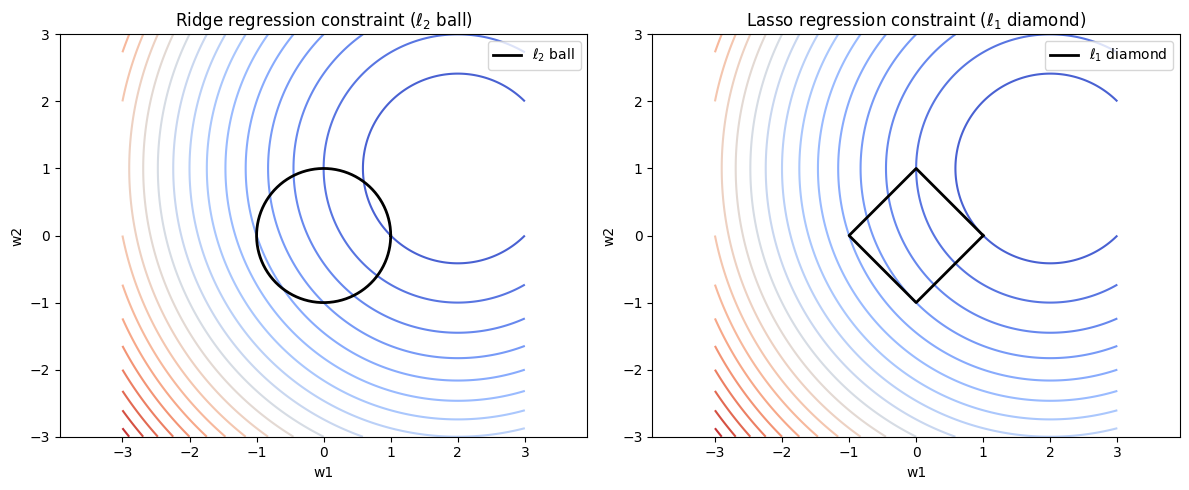

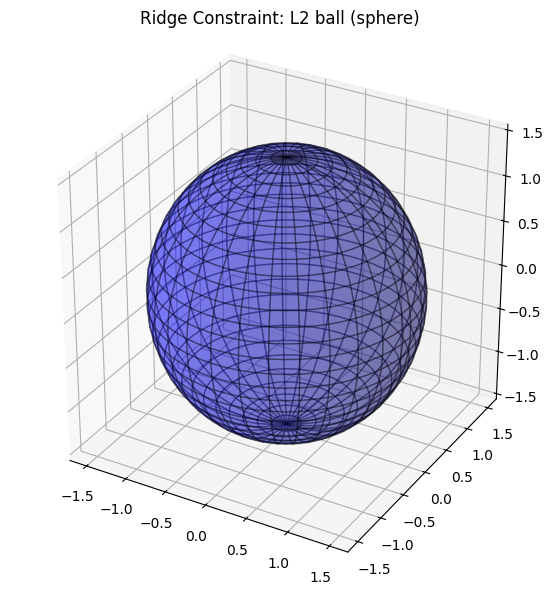

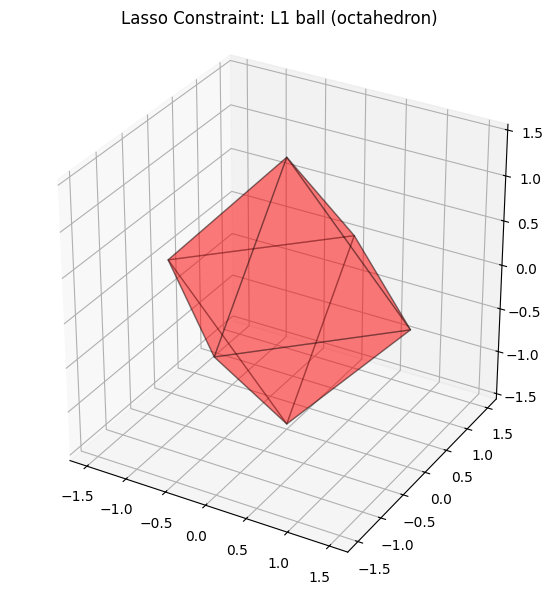

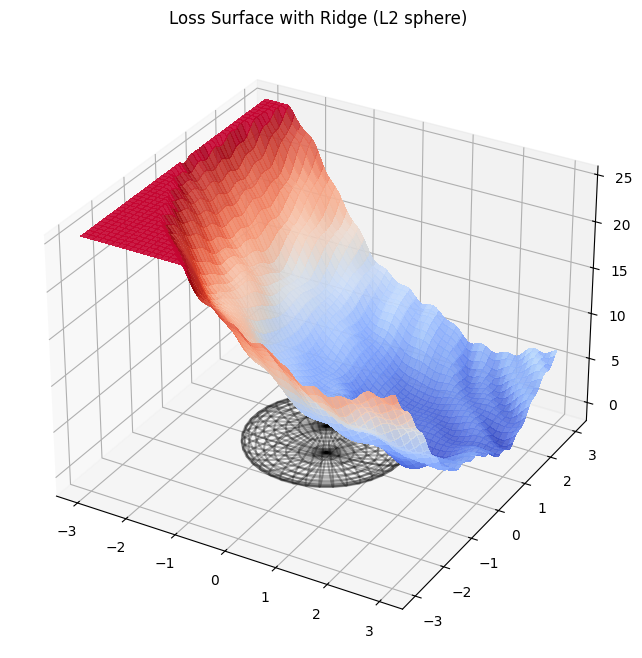

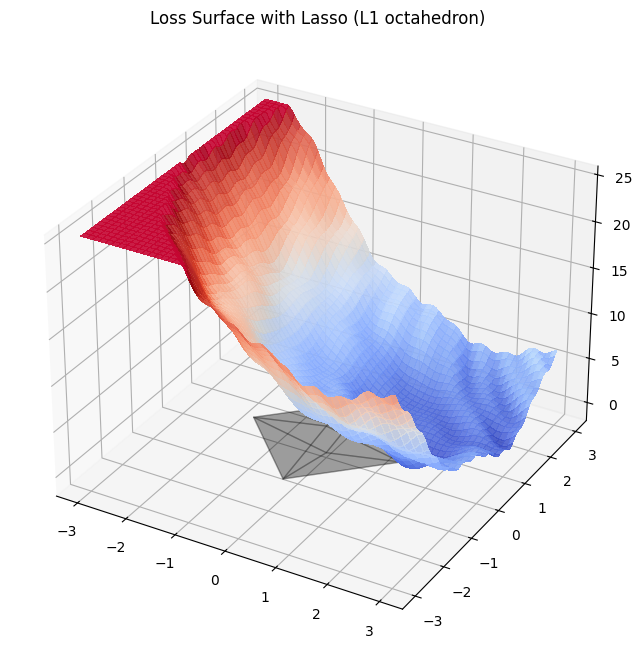

In [15]:
# ridge_lasso_constraints_and_loss.py
# Show (1) constraint sets alone, and (2) constraint sets intersecting with the loss surface

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 2D Visualization (Contours)
# -----------------------------
w1 = np.linspace(-3, 3, 400)
w2 = np.linspace(-3, 3, 400)
W1, W2 = np.meshgrid(w1, w2)

# Example quadratic loss centered at (2,1)
loss = (W1 - 2)**2 + (W2 - 1)**2

# Ridge (L2 ball)
theta = np.linspace(0, 2*np.pi, 200)
ridge_x = np.cos(theta)
ridge_y = np.sin(theta)

# Lasso (L1 diamond)
lasso_x = np.array([1, 0, -1, 0, 1])
lasso_y = np.array([0, 1, 0, -1, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ridge
axes[0].contour(W1, W2, loss, levels=20, cmap="coolwarm")
axes[0].plot(ridge_x, ridge_y, 'k-', linewidth=2, label=r'$\ell_2$ ball')
axes[0].set_title("Ridge regression constraint ($\\ell_2$ ball)")
axes[0].set_xlabel("w1")
axes[0].set_ylabel("w2")
axes[0].axis('equal')
axes[0].legend()

# Lasso
axes[1].contour(W1, W2, loss, levels=20, cmap="coolwarm")
axes[1].plot(lasso_x, lasso_y, 'k-', linewidth=2, label=r'$\ell_1$ diamond')
axes[1].set_title("Lasso regression constraint ($\\ell_1$ diamond)")
axes[1].set_xlabel("w1")
axes[1].set_ylabel("w2")
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()


radius = 1.5  # constraint size

# --------------------
# Constraint sets
# --------------------
def plot_ridge_constraint():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color='blue', alpha=0.3, edgecolor='k')
    ax.set_title("Ridge Constraint: L2 ball (sphere)")
    ax.set_box_aspect([1,1,1])
    plt.show()

def plot_lasso_constraint():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    verts = np.array([
        [ radius, 0, 0],
        [-radius, 0, 0],
        [0,  radius, 0],
        [0, -radius, 0],
        [0, 0,  radius],
        [0, 0, -radius]
    ])
    faces = [
        [verts[0], verts[2], verts[4]],
        [verts[2], verts[1], verts[4]],
        [verts[1], verts[3], verts[4]],
        [verts[3], verts[0], verts[4]],
        [verts[0], verts[2], verts[5]],
        [verts[2], verts[1], verts[5]],
        [verts[1], verts[3], verts[5]],
        [verts[3], verts[0], verts[5]],
    ]
    poly = Poly3DCollection(faces, alpha=0.3, facecolor='red', edgecolor='k')
    ax.add_collection3d(poly)
    ax.set_title("Lasso Constraint: L1 ball (octahedron)")
    ax.set_box_aspect([1,1,1])
    plt.show()

# --------------------
# Loss surface
# --------------------
def rugged_bowl(W1, W2, center=(2,1)):
    c1, c2 = center
    Z = (W1 - c1)**2 + (W2 - c2)**2
    R = np.sqrt(W1**2 + W2**2)
    Z += 0.70*np.sin(2.6*W1)*np.cos(2.2*W2)
    Z += 0.35*np.sin(5.5*R)
    Z += 0.25*np.cos(4.2*W1*W2)
    Z += 0.20*np.sin(6.8*W1 + 3.1*W2)
    Z += 0.15*(R**1.3)
    zcap = np.percentile(Z, 92)
    return np.minimum(Z, zcap)

# --------------------
# Loss + constraints
# --------------------
def plot_loss_with_ridge():
    w = np.linspace(-3, 3, 200)
    W1, W2 = np.meshgrid(w, w)
    Z = rugged_bowl(W1, W2)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection="3d")

    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(Z, cmap=plt.cm.coolwarm, vert_exag=0.9, blend_mode='soft')
    ax.plot_surface(W1, W2, Z, facecolors=rgb, linewidth=0, antialiased=False, shade=False, alpha=0.9)

    # Ridge = sphere
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(x, y, z, color="black", alpha=0.3)

    ax.set_title("Loss Surface with Ridge (L2 sphere)")
    plt.show()

def plot_loss_with_lasso():
    w = np.linspace(-3, 3, 200)
    W1, W2 = np.meshgrid(w, w)
    Z = rugged_bowl(W1, W2)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection="3d")

    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(Z, cmap=plt.cm.coolwarm, vert_exag=0.9, blend_mode='soft')
    ax.plot_surface(W1, W2, Z, facecolors=rgb, linewidth=0, antialiased=False, shade=False, alpha=0.9)

    # Lasso = octahedron
    verts = np.array([
        [ radius, 0, 0],
        [-radius, 0, 0],
        [0,  radius, 0],
        [0, -radius, 0],
        [0, 0,  radius],
        [0, 0, -radius]
    ])
    faces = [
        [verts[0], verts[2], verts[4]],
        [verts[2], verts[1], verts[4]],
        [verts[1], verts[3], verts[4]],
        [verts[3], verts[0], verts[4]],
        [verts[0], verts[2], verts[5]],
        [verts[2], verts[1], verts[5]],
        [verts[1], verts[3], verts[5]],
        [verts[3], verts[0], verts[5]],
    ]
    poly = Poly3DCollection(faces, alpha=0.2, facecolor="black", edgecolor="k")
    ax.add_collection3d(poly)

    ax.set_title("Loss Surface with Lasso (L1 octahedron)")
    plt.show()

# --------------------
# Run
# --------------------
plot_ridge_constraint()
plot_lasso_constraint()
plot_loss_with_ridge()
plot_loss_with_lasso()


# Orthogonal and Normalized Vectors in 3D

Here’s a 3D plot of **orthogonal, normalized vectors** (the standard basis in \(\mathbb{R}^3\)):

- **Red (v1)** → unit vector along the x-axis  
- **Green (v2)** → unit vector along the y-axis  
- **Blue (v3)** → unit vector along the z-axis  

They are:

- **Orthogonal** → dot product = 0 between any pair.  
- **Normalized** → length = 1.  

The dashed arrows show the **original unnormalized vectors** (different lengths).  
The solid arrows show the **normalized versions** (all length 1).  

This is the geometric idea behind **whitening**:  
after normalization/orthogonalization, the feature axes become perpendicular and of equal length.  
That’s why algebraic formulas for **ridge** and **lasso** simplify when assuming \(X^T X = I\).


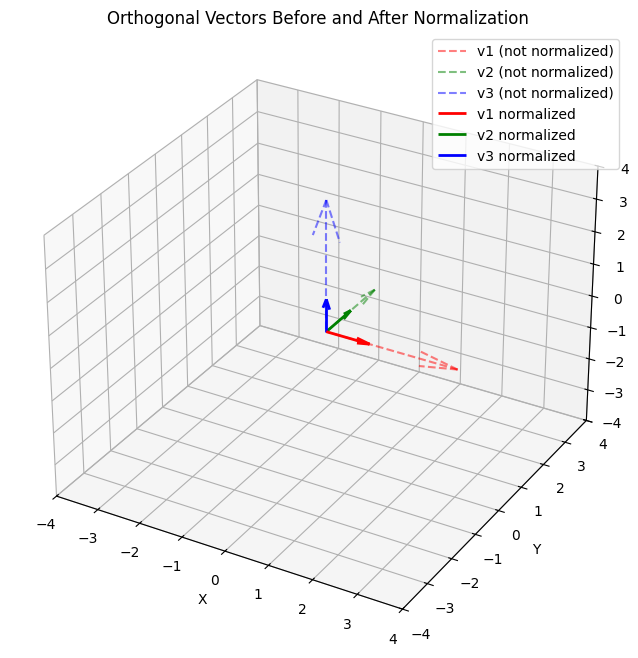

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define three orthogonal but not normalized vectors
v1 = np.array([3, 0, 0])
v2 = np.array([0, 2, 0])
v3 = np.array([0, 0, 4])

# Normalized versions
v1n = v1 / np.linalg.norm(v1)
v2n = v2 / np.linalg.norm(v2)
v3n = v3 / np.linalg.norm(v3)

# Plot non-normalized (dashed)
ax.quiver(0, 0, 0, v1[0], v1[1], v1[2], color='r', linestyle='dashed', alpha=0.5, label='v1 (not normalized)')
ax.quiver(0, 0, 0, v2[0], v2[1], v2[2], color='g', linestyle='dashed', alpha=0.5, label='v2 (not normalized)')
ax.quiver(0, 0, 0, v3[0], v3[1], v3[2], color='b', linestyle='dashed', alpha=0.5, label='v3 (not normalized)')

# Plot normalized (solid)
ax.quiver(0, 0, 0, v1n[0], v1n[1], v1n[2], color='r', linewidth=2, label='v1 normalized')
ax.quiver(0, 0, 0, v2n[0], v2n[1], v2n[2], color='g', linewidth=2, label='v2 normalized')
ax.quiver(0, 0, 0, v3n[0], v3n[1], v3n[2], color='b', linewidth=2, label='v3 normalized')

# Labels and formatting
ax.set_xlim([-4, 4])
ax.set_ylim([-4, 4])
ax.set_zlim([-4, 4])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Orthogonal Vectors Before and After Normalization')
ax.legend()

plt.show()
